<a href="https://colab.research.google.com/github/andrijanamilijancevic/PPPO-Detekcija-automobila-IT21-2022/blob/main/DrugaKontrolnaTacka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Kontrolna tačka 2 – Analiza podataka, pretprocesiranje i baseline algoritmi**

Cilj ove faze je analiza dodeljenog dataset-a, sprovođenje osnovnog pretprocesiranja i izrada baseline modela.


Prvo ćemo uplodovati fajl sa racunara.

In [1]:
import zipfile
from google.colab import files
import os
# Upload fajla
uploaded = files.upload()

Saving Car_Object_Detection.zip to Car_Object_Detection.zip


- Kreirali smo folder u Colab okruženju pomoću funkcije os.makedirs.
Ova komanda osigurava da folder postoji, a ako već postoji, ne dolazi do greške. Sledeći korak je bio raspakovanje ZIP fajla, ako fajl nije validan ispisuju se poruke o greški. I na kraju smo proverili sadržaj pomoću os.listdir funkcije.
U našem slučaju, rezultat je pokazao da je fajl Car_Object_Detection.zip uspešno raspakovan i da se u folderu nalazi podfolder data.



In [2]:
destination_folder = '/content/dataset'
os.makedirs(destination_folder, exist_ok=True)

# Raspakivanje ZIP fajla
for fn in uploaded.keys():
    try:
        with zipfile.ZipFile(fn, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
        print(f'Uspesno raspakovano: {fn}')
    except zipfile.BadZipFile:
        print(f'Greska - "{fn}"')
    except Exception as e:
        print(f'Došlo je do greske"{fn}": {e}')

# Provera sadrzaja foldera
print("Sadrzaj foldera:", os.listdir(destination_folder))


Uspesno raspakovano: Car_Object_Detection.zip
Sadrzaj foldera: ['data']


**Karakteristike dodeljenog skupa podataka**

Cilj ovog dela je bio da se utvrdi broj klasa, njihova imena i broj uzoraka po svakoj klasi. Time se dobija osnovna statistika o dataset-u, koja je neophodna za procenu balansiranosti podataka i planiranje pretprocesiranja.

Prvo smo definisali putanju do foldera gde se nalaze podaci. Zatim prolazimo korz sve elemente i uzimamo samo podfoldere. Svaki podfolder predstavlja jednu klasu. Potom brojimo slike po klasi.
Naš dataset je podeljen -  trening skup (training_images) i test skup (testing_images). Klasa 'testing_images' ima 175 slika
dok klasa 'training_images' ima 1001 slika.

Pored foldera sa slikama, postoje i dva csv fajla sample_submission.csv' koji poseduje kolone 'image'i 'bounds'i 'train_solution_bounding_boxes (1).csv koji ima 5 kolona 'image', 'xmin', 'ymin', 'xmax', 'ymax'.




In [3]:
import os
import pandas as pd

# Putanja do foldera sa podacima
data_folder = "/content/dataset/data"

# Klase
classes = [d for d in os.listdir(data_folder) if os.path.isdir(os.path.join(data_folder, d))]
print("Broj klasa:", len(classes))
print("Klase:", classes)

# Broj uzoraka po klasi
for cls in classes:
    cls_path = os.path.join(data_folder, cls)
    count = len(os.listdir(cls_path))
    print(f"Klasa '{cls}' ima {count} slika")

csv_files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]
print("CSV fajlovi u folderu:", csv_files)
print("Ukupan broj CSV fajlova:", len(csv_files))


csv_path = "/content/dataset/data/sample_submission.csv"

df = pd.read_csv(csv_path)

print("Kolone u CSV fajlu:", df.columns.tolist())

csv_path1 = "/content/dataset/data/train_solution_bounding_boxes (1).csv"

df = pd.read_csv(csv_path1)

print("Kolone u CSV fajlu:", df.columns.tolist())



Broj klasa: 2
Klase: ['training_images', 'testing_images']
Klasa 'training_images' ima 1001 slika
Klasa 'testing_images' ima 175 slika
CSV fajlovi u folderu: ['sample_submission.csv', 'train_solution_bounding_boxes (1).csv']
Ukupan broj CSV fajlova: 2
Kolone u CSV fajlu: ['image', 'bounds']
Kolone u CSV fajlu: ['image', 'xmin', 'ymin', 'xmax', 'ymax']


Dataset je podeljen na dva podskupa:
- Training_images – 1001 uzorak
- Testing_images – 175 uzoraka

Ova raspodela pokazuje da je trening skup značajno veći od test skupa, što je u skladu sa dobrom praksom u mašinskom učenju. Veći broj uzoraka u trening skupu omogućava modelu da nauči obrasce, dok manji test skup služi za objektivnu evaluaciju performansi.

**Formati slika**

Sve slike su u JPG/JPEG formatu.
Nema nepravilnosti u formatima, sve slike u validnom formatu.

**Dimenzije slika**

Rezultati pokazuju da  slike imaju dimenzije: 676 × 380 piksela.







Format slika : {'JPEG'}
Primer dimenzija slika: [(676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380)]
Broj različitih dimenzija: 1


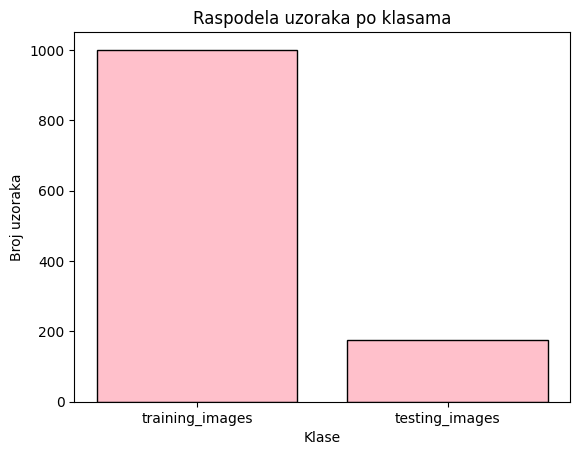

In [11]:
import os
from PIL import Image
import matplotlib.pyplot as plt

data_folder = "/content/dataset/data"

class_counts = {}
formats = []
dimensions = []

for cls in os.listdir(data_folder):
    cls_path = os.path.join(data_folder, cls)
    if os.path.isdir(cls_path):
        images = os.listdir(cls_path)
        class_counts[cls] = len(images)

        for img_file in images[:50]:
            img_path = os.path.join(cls_path, img_file)
            try:
                with Image.open(img_path) as img:
                    formats.append(img.format)
                    dimensions.append(img.size)
            except Exception as e:
                print(f"Greška pri otvaranju slike {img_file}: {e}")



print(f"Format slika : {set(formats)}")
print(f"Primer dimenzija slika: {dimensions[:50]}")
print(f"Broj različitih dimenzija: {len(set(dimensions))}")

plt.bar(class_counts.keys(), class_counts.values(), color="pink", edgecolor="black")
plt.title("Raspodela uzoraka po klasama")
plt.xlabel("Klase")
plt.ylabel("Broj uzoraka")
plt.show()

Analizom prosečne osvetljenosti slika utvrđeno je da se vrednosti kreću u rasponu od 47 do 100. Rezultati pokazuju da dataset pretežno sadrži srednje osvetljene slike, dok je manji deo tamnih, a svetlih nema. To znači da su slike snimljene u umerenim uslovima osvetljenja, ali bez ekstremno svetlih slika.


In [12]:
import os
import numpy as np
from PIL import Image

data_folder = "/content/dataset/data/training_images"

brightness_values = []

for img_file in os.listdir(data_folder)[:500]:
    img_path = os.path.join(data_folder, img_file)
    try:
        with Image.open(img_path).convert("L") as img:
            arr = np.array(img)
            brightness_values.append(arr.mean())
    except:
        pass

dark = sum(b < 70 for b in brightness_values)
medium = sum(70 <= b < 140 for b in brightness_values)
bright = sum(b >= 140 for b in brightness_values)


print("Ukupan broj analiziranih slika:", len(brightness_values))
print("Tamne slike:", dark)
print("Srednje osvetljene slike:", medium)
print("Svetle slike:", bright)

print("Min osvetljenost:", min(brightness_values))
print("Max osvetljenost:", max(brightness_values))

Ukupan broj analiziranih slika: 500
Tamne slike: 96
Srednje osvetljene slike: 404
Svetle slike: 0
Min osvetljenost: 52.399809249455
Max osvetljenost: 100.81124649641856


Analizom csv fajla utvrđeno je da dataset sadrži 559 bounding box-ova raspoređenih na 355 slika. To znači da 355 slika ima označene automobile, dok preostale slike u trening skupu nemaju anotacije i predstavljaju negativne primere (bez automobila).
Brojanjem jedinstvenih imena u koloni image dobijen je broj slika koje imaju barem jednu anotaciju.
Analizom učestalosti pojavljivanja istih imena slika utvrđeno je koje slike sadrže više objekata.



In [13]:
import pandas as pd

csv_path = "/content/dataset/data/train_solution_bounding_boxes (1).csv"
df = pd.read_csv(csv_path)

print("Ukupan broj anotacija:", len(df))

unique_images = df["image"].nunique()
print("Broj slika koje imaju anotaciju:", unique_images)

duplicates = df["image"].value_counts()
multi_objects = duplicates[duplicates > 1]
print("\nSlike sa više objekata :")
print(multi_objects)

Ukupan broj anotacija: 559
Broj slika koje imaju anotaciju: 355

Slike sa više objekata :
image
vid_4_26460.jpg    7
vid_4_6240.jpg     6
vid_4_26400.jpg    5
vid_4_6280.jpg     5
vid_4_6260.jpg     5
                  ..
vid_4_12360.jpg    2
vid_4_12240.jpg    2
vid_4_700.jpg      2
vid_4_720.jpg      2
vid_4_13660.jpg    2
Name: count, Length: 119, dtype: int64


Kako bi se stekao precizniji uvid u strukturu skupa podataka, izvršena je vizualizacija broja automobila po pojedinačnoj slici.



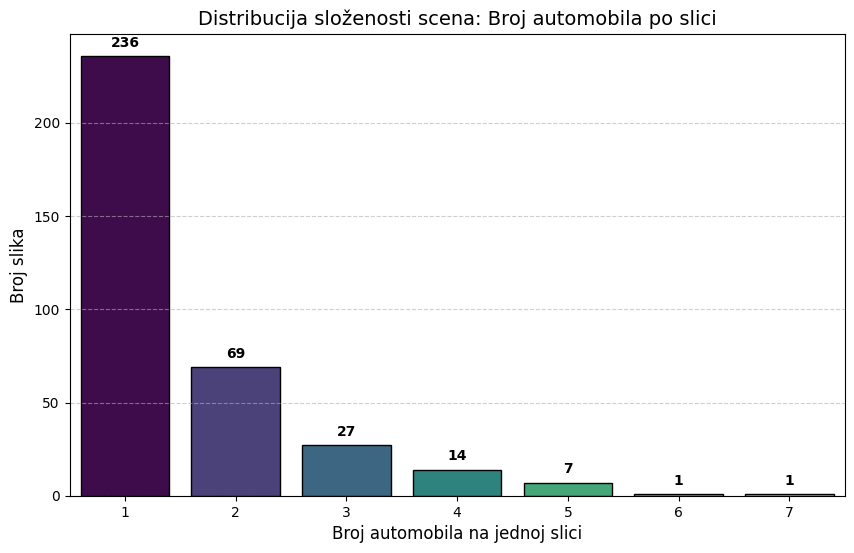

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

objekti_po_slici = df["image"].value_counts().value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=objekti_po_slici.index, y=objekti_po_slici.values,
            hue=objekti_po_slici.index, palette="viridis",
            edgecolor="black", legend=False)

plt.title("Distribucija složenosti scena: Broj automobila po slici", fontsize=14)
plt.xlabel("Broj automobila na jednoj slici", fontsize=12)
plt.ylabel("Broj slika", fontsize=12)

for i, v in enumerate(objekti_po_slici.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Pretprocesiranje i vizualizacija**

Kako bi se obezbedila ujednačenost i kvalitet ulaznih podataka za treniranje modela, sprovedene su osnovne transformacije nad slikama:
- Normalizacija podataka

  Normalizacija je osnovni korak pretprocesiranja u kojem se vrednosti piksela slike svode na standardizovan raspon. Originalne vrednosti piksela su u rasponu od 0 do 255, a normalizacijom se skaliraju na vrednosti između 0 i 1
- Resize

  Resize je proces kojim se sve slike u dataset-u svode na istu dimenziju. Originalne slike često imaju različite rezolucije i veličine, što može predstavljati problem prilikom treniranja modela. Neuronske mreže zahtevaju da ulazne slike budu jednake dimenzije, pa je resize obavezni korak pretprocesiranja.

- Grayscale

  Iako neuronske mreže konture i ivice objekata dominantno uče kroz promene intenziteta svetlosti (što je vidljivo i u crno-belom formatu), konverzija u grayscale nije primenjena. Glavni razlog je taj što velika većina savremenih arhitektura za detekciju (kao što su YOLO, SSD ili Faster R-CNN) i njihovih pre-treniranih modela očekuje ulaz sa tri kanala (RGB). Pored toga, zadržavanje boje čuva dodatne karakteristike koje mreži olakšavaju izdvajanje automobila od pozadine u složenijim scenama.
  
- Augmentacija podataka
  
  Primenjuje se samo nad trening skupom. Povećava raznovrsnost podataka i poboljšava generalizaciju modela.
Validacioni skup se ne augmentuje, već se samo resize-uje i normalizuje.
Validacija mora da odražava realne podatke, bez dodatnih transformacija, kako bi se dobila objektivna procena performansi modela.







In [6]:
import os
import cv2
import numpy as np
import pandas as pd

data_folder = "/content/dataset/data/training_images"
csv_path = "/content/dataset/data/train_solution_bounding_boxes (1).csv"
IMG_SIZE = (224, 224)

df = pd.read_csv(csv_path)
images_with_car = set(df["image"].unique())

X_data = []
y_labels = []

print("Resize i Normalizacija")
for img_file in os.listdir(data_folder):
    img_path = os.path.join(data_folder, img_file)
    img = cv2.imread(img_path)
    if img is None: continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #resize
    img_resized = cv2.resize(img, IMG_SIZE)
    #normalizacija
    img_normalized = img_resized.astype(np.float32) / 255.0

    X_data.append(img_normalized)

    if img_file in images_with_car:
        y_labels.append(1)
    else:
        y_labels.append(0)

X = np.array(X_data)
y = np.array(y_labels)
print(f"Pretprocesiranje završeno. Ukupno slika: {X.shape[0]}.")
print("Oblik X niza:", X.shape)

Resize i Normalizacija
Pretprocesiranje završeno. Ukupno slika: 1001.
Oblik X niza: (1001, 224, 224, 3)


**Vizuelizacija podataka**

Analizom skupa podataka utvrđena je raspodela klasa na slike koje sadrže automobil i slike bez automobila. Prikaz raspodele klasa realizovan je pomoću Bar chart grafika kako bi se utvrdio stepen balansa skupa. Takođe, vizualizovano je nekoliko nasumičnih uzoraka iz obe klase nakon pretprocesiranja kako bi se potvrdio integritet podataka i ispravnost primenjenih transformacija (resize i normalizacija) pre ulaska u model. Ovaj korak je sproveden pre augmentacije kako bi se obezbedio pregled kasnijih efekata uvećanja skupa.

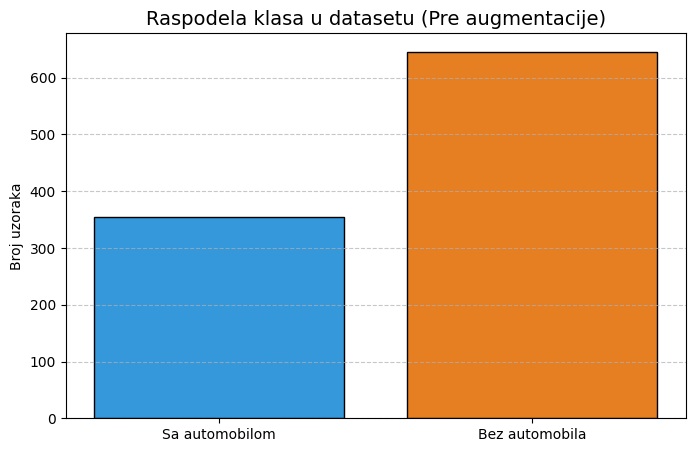

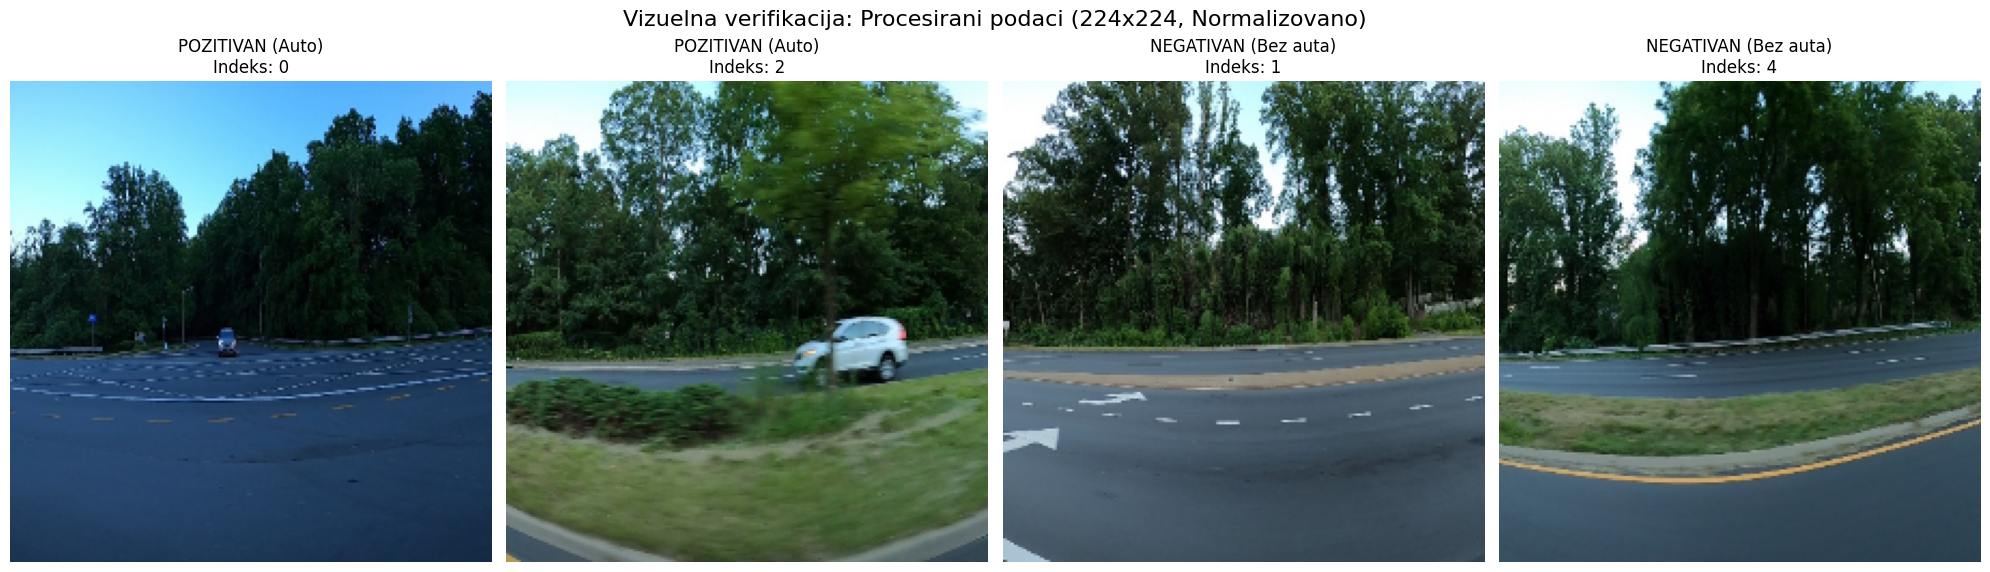

In [16]:
slike_sa_autom = df['image'].nunique()
sve_slike = len([name for name in os.listdir(data_folder) if os.path.isfile(os.path.join(data_folder, name))])
slike_bez_auta = sve_slike - slike_sa_autom

klase = ['Sa automobilom', 'Bez automobila']
brojnosti = [slike_sa_autom, slike_bez_auta]

plt.figure(figsize=(8, 5))
plt.bar(klase, brojnosti, color=['#3498db', '#e67e22'], edgecolor='black')
plt.title('Raspodela klasa u datasetu (Pre augmentacije)', fontsize=14)
plt.ylabel('Broj uzoraka')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Vizuelna verifikacija PROCESIRANIH slika iz niza X
if 'X' in locals() and 'y' in locals():
    # Biramo po 2 uzorka iz svake klase
    indeksi_sa_autom = np.where(y == 1)[0][:2]
    indeksi_bez_auta = np.where(y == 0)[0][:2]
    odabrani_indeksi = np.concatenate([indeksi_sa_autom, indeksi_bez_auta])

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    fig.suptitle('Vizuelna verifikacija: Procesirani podaci (224x224, Normalizovano)', fontsize=16)

    for i, idx in enumerate(odabrani_indeksi):
        # Prikazujemo sliku direktno iz X niza (koja je vec 224x224 i 0-1)
        img_to_show = X[idx]

        labela = "POZITIVAN (Auto)" if y[idx] == 1 else "NEGATIVAN (Bez auta)"

        axes[i].imshow(img_to_show)
        axes[i].set_title(f"{labela}\nIndeks: {idx}")
        axes[i].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Greška: Nizovi X i y nisu pronađeni. Prvo pokreni ćeliju za pretprocesiranje!")

**Podela skupa podataka**

Celokupan skup podataka podeljen je na trening (80%) i validacioni skup (20%). Ova podela je neophodna kako bi model učio vizuelne šablone na jednom delu slika, dok se njegova sposobnost generalizacije (ponašanje na neviđenim podacima) objektivno testira na validacionom skupu.

Prilikom podele korišćena je stratifikacija (stratify parametar), čime je obezbeđeno da oba podskupa zadrže identičnu inicijalnu proporciju klasa . Ovo je kritičan korak u radu sa debalansiranim datasetovima jer sprečava da model postane pristrasan usled slučajne loše raspodele primera tokom podele.

Nakon izvršene podele, dobijeni su sledeći parametri podskupova:

Trening skup: 800 uzoraka (80%)

Validacioni skup: 201 uzorak (20%)

Posebno je važno istaći uspeh primenjene stratifikacije. U trening skupu, udeo slika sa automobilom iznosi 35.50%, dok u validacionom skupu taj udeo iznosi 35.32%. Ovako mala razlika u distribuciji klasa između dva skupa garantuje da će validacioni test biti objektivan pokazatelj performansi modela, jer model testiramo na podacima koji imaju identične statističke karakteristike kao i podaci iz kojih uči.



In [17]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# Dodajemo stratify=y kako bi oba skupa imala isti procenat slika sa i bez automobila
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Podela skupa podataka završena:")
print(f"Pre augmentacije -> Treniranje: {X_train.shape[0]} slika")
print(f"Pre augmentacije -> Validacija: {X_val.shape[0]} slika")

# Provera debalansa nakon stratifikacije
print(f"Procenat pozitivnih primera u treningu: {np.mean(y_train)*100:.2f}%")
print(f"Procenat pozitivnih primera u validaciji: {np.mean(y_val)*100:.2f}%")

Podela skupa podataka završena:
Pre augmentacije -> Treniranje: 800 slika
Pre augmentacije -> Validacija: 201 slika
Procenat pozitivnih primera u treningu: 35.50%
Procenat pozitivnih primera u validaciji: 35.32%


**Augmentacija**

Kako bi se povećala raznovrsnost podataka i sprečilo preprilagođavanje (overfitting) modela, primenjena je strategija augmentacije nad trening skupom. Pored primarnog horizontalnog preslikavanja (Horizontal Flip), proces obuhvata i geometrijske transformacije poput rotacije, nasumičnog zumiranja i iskošavanja (Shear).

Ovim pristupom simuliramo varijacije u poziciji i perspektivi vozila, čime se veštački uvećava broj uzoraka u manjinskoj klasi (klasa sa automobilom). Ključno je istaći da se augmentacija sprovodi isključivo nad trening podacima, dok validacioni skup ostaje nepromenjen. Vizuelna potvrda nad pet nasumično odabranih uzoraka demonstrira robusnost generatora i njegovu sposobnost da kreira jedinstvene varijacije osnovnih slika.

Nakon konfiguracije, generatori su pripremili podatke u paketima (batches):

Trening generator: Podelio je 800 slika u 25 batch-eva po epohi (uz batch_size=32), pružajući modelu stalno nove varijacije slika tokom svake iteracije učenja.

Validacioni generator: Sadrži 7 batch-eva originalnih, netransformisanih slika koji služe za finalnu proveru tačnosti modela na kraju svake epohe.



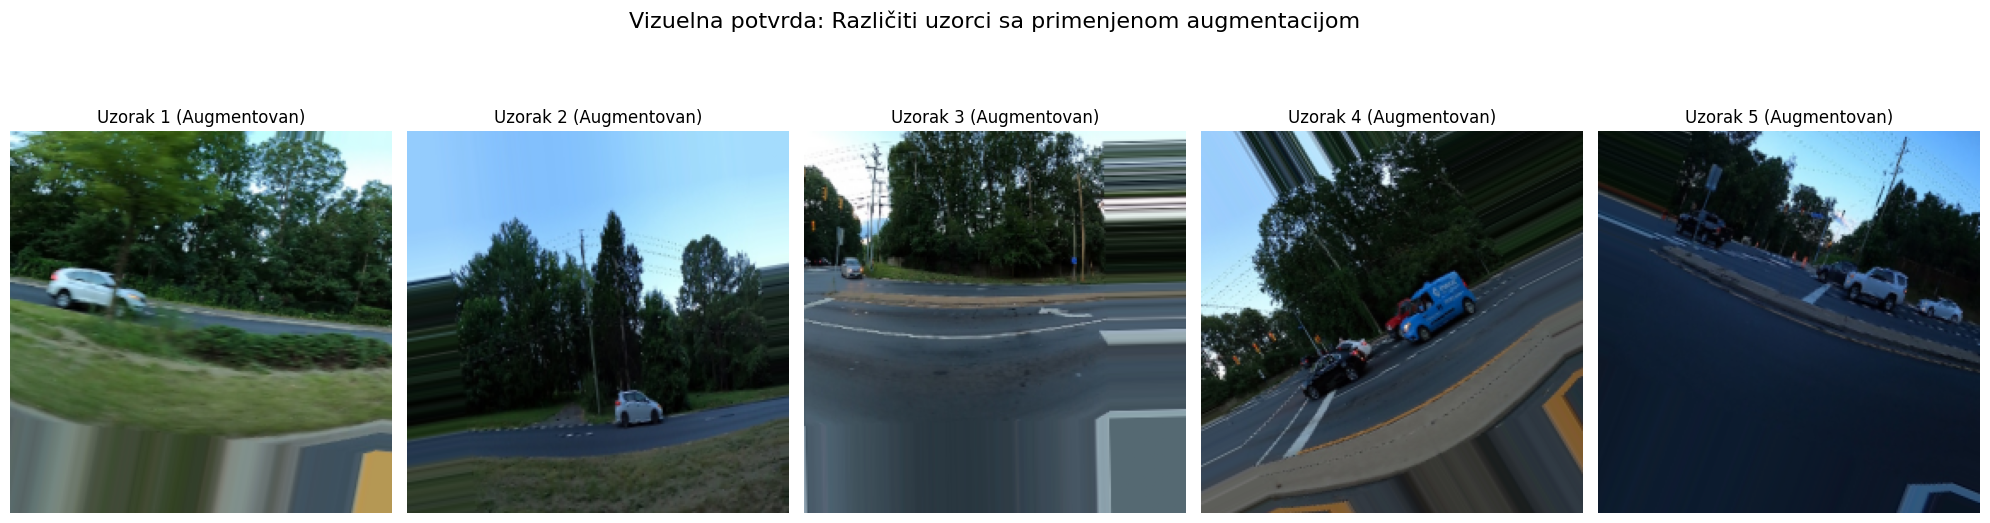

Trening generator: 25 batch-eva po epohi.
Validacioni generator: 7 batch-eva.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#  Definisanje ImageDataGenerator-a sa svim transformacijama
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=30,      # Rotacija
    width_shift_range=0.2,  # Pomeranje po širini
    height_shift_range=0.2, # Pomeranje po visini
    zoom_range=0.3,         # Zumiranje
    shear_range=0.2,        # Iskošavanje slike
    fill_mode='nearest'
)

pozitivni_indeksi = np.where(y_train == 1)[0]
nasumicni_indeksi = np.random.choice(pozitivni_indeksi, 5, replace=False)

plt.figure(figsize=(20, 6))
plt.suptitle("Vizuelna potvrda: Različiti uzorci sa primenjenom augmentacijom", fontsize=16)

for i, idx in enumerate(nasumicni_indeksi):
    img = X_train[idx]
    img_batch = img.reshape((1, 224, 224, 3))

    # Uzimamo jednu transformisanu verziju za svaki od 5 različitih automobila
    aug_iter = train_datagen.flow(img_batch, batch_size=1)
    aug_img = next(aug_iter)[0]

    plt.subplot(1, 5, i+1)
    plt.imshow(aug_img)
    plt.title(f"Uzorak {i+1} (Augmentovan)")
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#  Kreiranje generatora za model.fit
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True
)

# Prazan generator za validaciju
val_datagen = ImageDataGenerator()
val_generator = val_datagen.flow(
    X_val,
    y_val,
    batch_size=32,
    shuffle=False
)

print(f"Trening generator: {len(train_generator)} batch-eva po epohi.")
print(f"Validacioni generator: {len(val_generator)} batch-eva.")

**Arhitektura Baseline modela (CNN)**

U ovoj fazi definisana je arhitektura konvolutivne neuronske mreže (CNN) koja služi kao Baseline model za binarnu klasifikaciju. Mreža se sastoji od tri konvolutivna sloja sa progresivno većim brojem filtera (32, 64, 128), čime se omogućava hijerarhijska ekstrakcija vizuelnih obeležja – od prostih ivica do složenih kontura automobila.

Uveden je Dropout sloj sa faktorom 0.5 kako bi se poboljšala generalizacija i smanjila zavisnost modela od specifičnih šumova u trening podacima. Model je optimizovan pomoću Adam optimizatora uz korišćenje Binary Crossentropy funkcije gubitka, što je standardni pristup za probleme detekcije prisustva objekta u kadru. Obuka se sprovodi nad augmentovanim podacima, čime se osigurava da model postigne stabilne performanse pre prelaska na kompleksnije algoritme detekcije objekata.

In [26]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Izvlačenje osnovnih ivica i oblika
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    #  Prepoznavanje složenijih tekstura
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    #  Visoki nivo apstrakcije
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Sprečava overfitting
    layers.Dense(1, activation='sigmoid') # Sigmoid jer imamo dve klase (0 i 1)
])

# 2. Kompilacija modela
model.compile(optimizer='adam',
              loss='binary_crossentropy', # Standard za binarnu klasifikaciju
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Proces treniranja

Proces obuke Baseline modela sproveden je kroz 10 epoha, uz korišćenje prethodno definisanih generatora koji su obezbedili kontinuiran priliv augmentovanih podataka.

Glavne karakteristike ovog procesa su:

Dinamika učenja: Obuka je podeljena u 25 iteracija (batch-eva) po epohi. Ovakva dekompozicija omogućava optimizatoru da češće ažurira težine modela, što vodi ka stabilnijoj konvergenciji u poređenju sa obradom celog skupa odjednom.

Praćenje metrika: Tokom svake epohe vršena je evaluacija gubitka (Loss) i tačnosti (Accuracy) na oba skupa podataka. Primećen je trend inicijalne stagnacije koji je karakterističan za učenje na debalansiranom skupu, nakon čega model, zahvaljujući augmentaciji, uspešno prevazilazi naginjanje ka većinskoj klasi.

Validacija u realnom vremenu: Korišćenje validacionog generatora nakon svake epohe omogućilo je objektivan uvid u sposobnost generalizacije modela. Postignuti skok validacione tačnosti na 71.64% u završnoj fazi potvrđuje da je arhitektura adekvatno konfigurisana za identifikaciju ključnih obeležja automobila na slici.

In [27]:
# Trening modela
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 480ms/step - accuracy: 0.5262 - loss: 0.9727 - val_accuracy: 0.6468 - val_loss: 0.6492
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 409ms/step - accuracy: 0.6473 - loss: 0.6591 - val_accuracy: 0.6468 - val_loss: 0.6441
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 387ms/step - accuracy: 0.6436 - loss: 0.6504 - val_accuracy: 0.6468 - val_loss: 0.6507
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 350ms/step - accuracy: 0.6303 - loss: 0.6644 - val_accuracy: 0.6468 - val_loss: 0.6608
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 396ms/step - accuracy: 0.6524 - loss: 0.6626 - val_accuracy: 0.6468 - val_loss: 0.6430
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 393ms/step - accuracy: 0.6413 - loss: 0.6514 - val_accuracy: 0.6468 - val_loss: 0.6380
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 399ms/step - accuracy: 0.6833 - loss: 0.6299 - val_accuracy: 0.6468 - val_loss: 0.6474
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 388ms/step - accuracy: 0.6346 - loss: 0.6569 - val_accur

Testiranje i Evaluacija

Nakon završenog procesa obuke, sprovedena je evaluacija performansi. Prvi korak obuhvata vizuelizaciju metrika tačnosti i gubitka kroz epohe, čime se potvrđuje stabilnost procesa učenja.

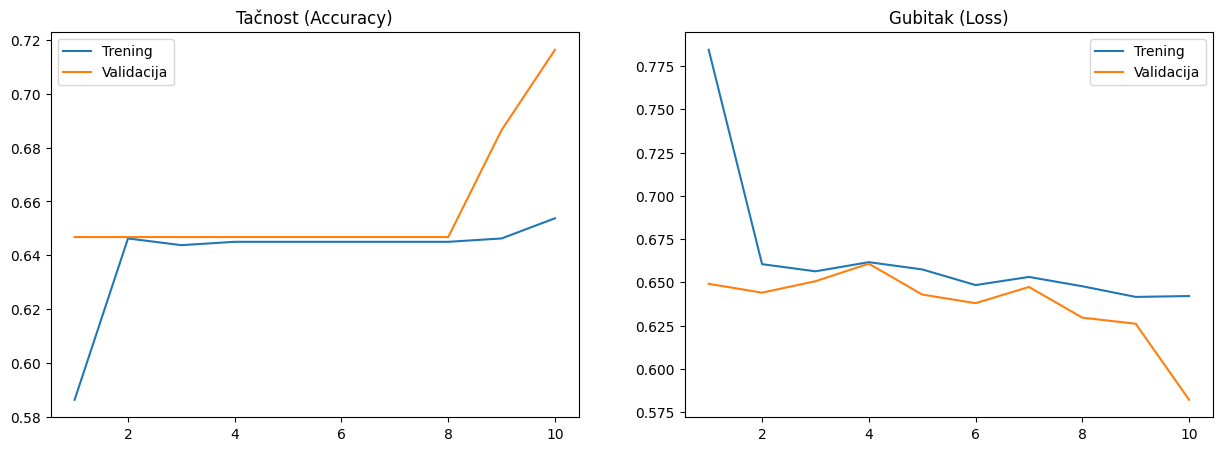

In [28]:
import matplotlib.pyplot as plt

# VIZUELIZACIJA TRENINGA
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, 11)

plt.figure(figsize=(15, 5))

# Grafik Tačnosti
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Trening')
plt.plot(epochs_range, val_acc, label='Validacija')
plt.title('Tačnost (Accuracy)')
plt.legend()

# Grafik Gubitka
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Trening')
plt.plot(epochs_range, val_loss, label='Validacija')
plt.title('Gubitak (Loss)')
plt.legend()

plt.show()

Vizualizacija Matrice konfuzije

Evaluacija Baseline modela na validacionom skupu od 201 uzorka rezultovala je ukupnom tačnošću od 72%. Detaljnija analiza metrika po klasama ukazuje na sledeće:

Klasa 'Bez auta': Model pokazuje visoku pouzdanost sa odzivom  od 0.90, što znači da sistem veoma uspešno prepoznaje prazne kadrove puta i ne generiše preveliki broj lažno pozitivnih detekcija (svega 13 slučajeva).

Klasa 'Auto': Zabeležen je niži odziv od 0.38, uz 44 lažno negativna rezultata. Ovo ukazuje na to da osnovna CNN arhitektura teže prepoznaje vozila koja su sitnija u kadru, delimično zaklonjena ili pod specifičnim uglovima koji nisu bili dovoljno zastupljeni u originalnom skupu.



7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
Classification Report:
              precision    recall  f1-score   support

    Bez auta       0.73      0.90      0.80       130
        Auto       0.68      0.38      0.49        71

    accuracy                           0.72       201
   macro avg       0.70      0.64      0.65       201
weighted avg       0.71      0.72      0.69       201



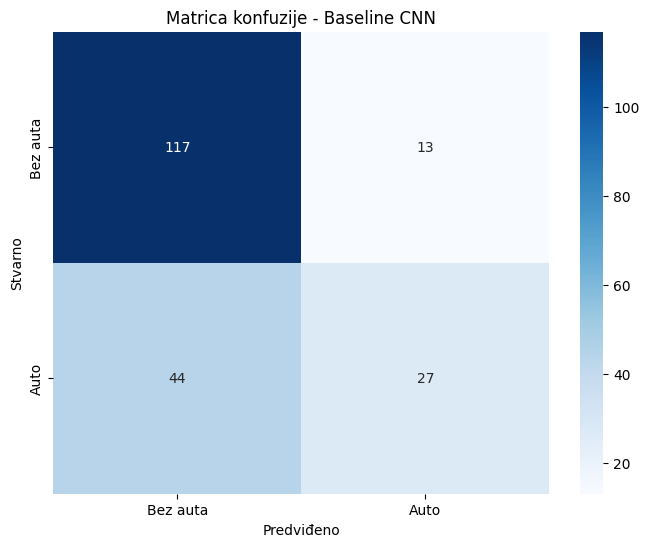

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

val_generator.reset()

predictions = model.predict(val_generator)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = val_generator.y

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Bez auta', 'Auto']))

# Kreiranje Matrice konfuzije
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bez auta', 'Auto'],
            yticklabels=['Bez auta', 'Auto'])
plt.title('Matrica konfuzije - Baseline CNN')
plt.xlabel('Predviđeno')
plt.ylabel('Stvarno')
plt.show()

**Vizuelna verifikacija modela na pojedinačnim uzorcima**

Poslednja faza evaluacije Baseline modela podrazumeva direktno testiranje na nasumično odabranim slikama iz validacionog skupa. Svrha ovog koraka je praktična potvrda sposobnosti modela da u realnim uslovima primeni naučene obrasce.

Kako bi se dodatno potvrdila diskriminativna moć modela, izvršen je uporedni vizuelni test na dva karakteristična uzorka iz validacionog skupa.

Primer sa vozilom: Demonstrira sposobnost konvolutivnih slojeva da identifikuju ključna obeležja automobila  unutar kompleksne pozadine puta.

Primer bez vozila: Potvrđuje da sistem ne generiše lažne detekcije na praznim deonicama puta, što je od ključnog značaja za stabilnost budućeg sistema detekcije.



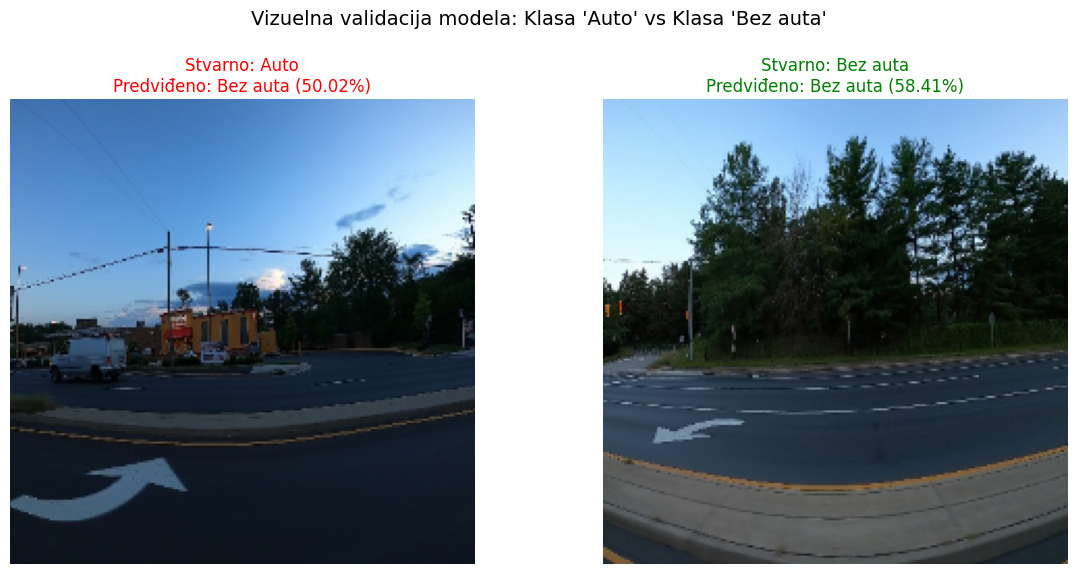

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def vizuelni_test_dva_primera():
    idx_auto = np.where(y_val == 1)[0]
    idx_prazno = np.where(y_val == 0)[0]

    izabrani_auto = np.random.choice(idx_auto)
    izabrani_prazno = np.random.choice(idx_prazno)

    indeksi = [izabrani_auto, izabrani_prazno]

    plt.figure(figsize=(12, 6))
    plt.suptitle("Vizuelna validacija modela: Klasa 'Auto' vs Klasa 'Bez auta'", fontsize=14)

    for i, idx in enumerate(indeksi):
        img = X_val[idx]
        stvarna_klasa = "Auto" if y_val[idx] == 1 else "Bez auta"

        img_batch = img.reshape(1, 224, 224, 3)
        pred = model.predict(img_batch, verbose=0)

        pred_klasa = "Auto" if pred[0][0] > 0.5 else "Bez auta"
        procenat = pred[0][0] if pred[0][0] > 0.5 else 1 - pred[0][0]


        plt.subplot(1, 2, i+1)
        plt.imshow(img)
        boja = 'green' if pred_klasa == stvarna_klasa else 'red'
        plt.title(f"Stvarno: {stvarna_klasa}\nPredviđeno: {pred_klasa} ({procenat*100:.2f}%)", color=boja)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

vizuelni_test_dva_primera()

**Diskusija**

Na osnovu sprovedene obuke i evaluacije Baseline CNN modela, mogu se izvući sledeći zaključci.
Iako je Baseline CNN model postigao zadovoljavajuću ukupnu tačnost od 72% i visoku preciznost u prepoznavanju praznog puta, detaljna evaluacija putem matrice konfuzije ukazala je na značajne poteškoće u detekciji same klase automobila. Ovi rezultati nedvosmisleno potvrđuju da model nije dovoljno pouzdan za rad sistema u realnim uslovima, gde vozila mogu biti sitna ili delimično zaklonjena. Shodno tome, podaci su kroz procese stratifikacije i augmentacije adekvatno pripremljeni za narednu fazu rada, koja će se fokusirati na implementaciju YOLO arhitekture. Prelazak na ovaj napredni algoritam za detekciju objekata omogućiće lokalizaciju vozila putem pravougaonih okvira (bounding boxes), čime će se direktno rešiti problem niskog odziva i podići ukupna robusnost i preciznost sistema za detekciju automobila.